<a href="https://colab.research.google.com/github/vaishnavipoojary2202/malicious-url-detection/blob/reese-model-training/notebooks/03_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
from scipy import sparse

# Load sparse feature matrices
X_train = sparse.load_npz(
    "/content/drive/MyDrive/ML mini/processed/X_train.npz"
)

X_test = sparse.load_npz(
    "/content/drive/MyDrive/ML mini/processed/X_test.npz"
)

# Load labels
y_train = pd.read_csv(
    "/content/drive/MyDrive/ML mini/processed/y_train.csv"
).values.ravel()

y_test = pd.read_csv(
    "/content/drive/MyDrive/ML mini/processed/y_test.csv"
).values.ravel()

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (9143, 50020)
Testing Features  : (2286, 50020)
Training Labels   : (9143,)
Testing Labels    : (2286,)


In [3]:
!pip install xgboost -q

In [4]:
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

results = []
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    trained_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

print("\nAll models trained successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

All models trained successfully!


In [6]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).round(4)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.9353,0.9322,0.9388,0.9355
2,Random Forest,0.9296,0.9345,0.9239,0.9292
0,Logistic Regression,0.9191,0.9315,0.9046,0.9179
1,Decision Tree,0.8766,0.8658,0.8915,0.8784


In [7]:
best_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_name]

print("Best Model:", best_name)

Best Model: XGBoost


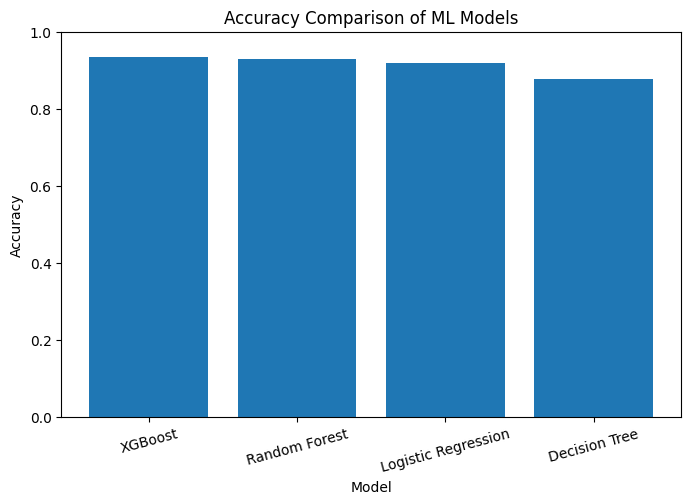

In [8]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Accuracy Comparison of ML Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.xticks(rotation=15)

plt.show()

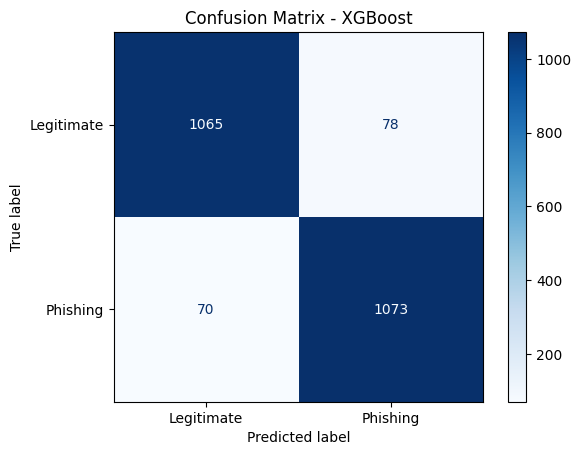

In [9]:
pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate","Phishing"]
)

disp.plot(cmap="Blues")

plt.title(f"Confusion Matrix - {best_name}")

plt.show()

In [10]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      1143
           1       0.93      0.94      0.94      1143

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286



In [11]:
os.makedirs("results/graphs", exist_ok=True)
os.makedirs("results/confusion_matrix", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Save metrics
results_df.to_csv("results/metrics.csv", index=False)

# Save model
joblib.dump(best_model, "models/best_model.pkl")

# Save accuracy graph
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Accuracy Comparison of ML Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("results/graphs/accuracy_comparison.png", dpi=300)
plt.close()

# Save confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate","Phishing"]
)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.savefig("results/confusion_matrix/confusion_matrix.png", dpi=300)
plt.close()

print("All files saved successfully!")

All files saved successfully!


In [12]:
from google.colab import files

files.download("models/best_model.pkl")
files.download("results/metrics.csv")
files.download("results/graphs/accuracy_comparison.png")
files.download("results/confusion_matrix/confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
## Research Paper Comparison

The proposed implementation was compared with the XGBoost model reported in the PhishHunter-XLD research paper.

| Model | Accuracy |
|--------|----------|
| PhishHunter-XLD (XGBoost) | 96.17% |
| Our XGBoost | 93.53% |

The difference in performance is attributed to differences in dataset size, feature engineering, TF-IDF representation, preprocessing, and model configuration.